In [1]:
# Load API key from .env file
from dotenv import load_dotenv
import os
import requests
import pandas as pd
from datetime import datetime, timedelta
import time

load_dotenv()  # Load environment variables from .env file
api_key = os.environ.get('POLYGON_API_KEY')

if api_key:
    print(f"API key loaded successfully (length: {len(api_key)} chars)")
else:
    print("POLYGON_API_KEY not found in .env file!")
    print("Create a .env file in the trading_brains folder with:")
    print("POLYGON_API_KEY=your-api-key-here")

API key loaded successfully (length: 32 chars)


# Data Loading from Polygon

In [2]:
# Load API key from environment

def fetch_polygon_1min_data(symbol: str, start_date: str, end_date: str, api_key: str) -> pd.DataFrame:
    """
    Fetch 1-minute OHLCV data from Polygon.io
    
    Args:
        symbol: Stock ticker symbol (e.g., 'SPY', 'QQQ', 'IWM')
        start_date: Start date in 'YYYY-MM-DD' format
        end_date: End date in 'YYYY-MM-DD' format
        api_key: Polygon.io API key
    
    Returns:
        DataFrame with columns: timestamp, open, high, low, close, volume, vwap
    """
    all_data = []
    multiplier = 1
    timespan = "minute"
    
    url = f"https://api.polygon.io/v2/aggs/ticker/{symbol}/range/{multiplier}/{timespan}/{start_date}/{end_date}"
    
    params = {
        "adjusted": "true",
        "sort": "asc",
        "limit": 100000,
        "apiKey": api_key
    }
    
    print(f"Fetching {symbol} data from {start_date} to {end_date}...")
    
    while url:
        response = requests.get(url, params=params)
        
        if response.status_code != 200:
            print(f"❌ Error: {response.status_code} - {response.text}")
            break
            
        data = response.json()
        
        if data.get("results"):
            all_data.extend(data["results"])
            print(f"  Fetched {len(data['results'])} bars (total: {len(all_data)})")
        
        # Handle pagination
        url = data.get("next_url")
        if url:
            params = {"apiKey": api_key}
            time.sleep(0.15)  # Rate limiting
    
    if not all_data:
        print("❌ No data received")
        return pd.DataFrame()
    
    # Convert to DataFrame
    df = pd.DataFrame(all_data)
    
    # Rename columns to standard format
    df = df.rename(columns={
        "t": "timestamp",
        "o": "open",
        "h": "high",
        "l": "low",
        "c": "close",
        "v": "volume",
        "vw": "vwap",
        "n": "num_trades"
    })
    
    # Convert timestamp from milliseconds to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df = df.set_index("timestamp")
    
    # Select relevant columns
    cols = ["open", "high", "low", "close", "volume"]
    if "vwap" in df.columns:
        cols.append("vwap")
    
    df = df[cols]
    
    print(f"✅ Loaded {len(df)} 1-minute bars for {symbol}")
    print(f"   Date range: {df.index.min()} to {df.index.max()}")
    
    return df

# Example: Fetch SPY (S&P 500 ETF) as a proxy for index
# Polygon free tier: 2 years of historical data
# Adjust dates as needed
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=425)).strftime("%Y-%m-%d")  # Last 2 years

# Uncomment to fetch data:
df = fetch_polygon_1min_data("SPY", start_date, end_date, api_key)

Fetching SPY data from 2025-01-12 to 2026-03-13...
  Fetched 50000 bars (total: 50000)
  Fetched 50000 bars (total: 100000)
  Fetched 50000 bars (total: 150000)
  Fetched 50000 bars (total: 200000)
  Fetched 50826 bars (total: 250826)
❌ Error: 429 - {"status":"ERROR","request_id":"a8716c409245cfef7e7f02f7c9347c86","error":"You've exceeded the maximum requests per minute, please wait or upgrade your subscription to continue. https://massive.com/pricing"}
✅ Loaded 250826 1-minute bars for SPY
   Date range: 2025-01-13 09:00:00 to 2026-03-12 23:59:00


In [3]:
df

,open,high,low,close,volume,vwap
timestamp,,,,,,
2025-01-13 09:00:00,578.2300,578.2300,576.2400,576.2400,8162.000000,576.8011
2025-01-13 09:01:00,576.1100,576.3400,576.0900,576.2100,4503.000000,576.1920
2025-01-13 09:02:00,576.1900,576.1900,575.9700,576.0000,2514.000000,576.0587
2025-01-13 09:03:00,575.8700,575.8700,575.6000,575.7600,3849.000000,575.6454
2025-01-13 09:04:00,575.5600,575.5600,575.0900,575.3800,4457.000000,575.2997
...,...,...,...,...,...,...
2026-03-12 23:55:00,666.6669,666.6669,666.6669,666.6669,190.110569,666.6916
2026-03-12 23:56:00,666.7000,666.7100,666.6600,666.6800,1487.248396,666.6948
2026-03-12 23:57:00,666.6900,666.6900,666.4788,666.4826,787.965470,666.5362


# Feature Engineering

Create technical indicators and derived features from OHLCV data for hourly price prediction.

In [4]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def create_features(df):
    """
    Create technical indicators and derived features from OHLCV data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: Open, High, Low, Close, Volume
        
    Returns:
    --------
    pd.DataFrame with additional features
    """
    df = df.copy()
    
    # ==================== Price-based Features ====================
    
    # Returns at different horizons
    df['returns_1m'] = df['close'].pct_change(1)
    df['returns_5m'] = df['close'].pct_change(5)
    df['returns_15m'] = df['close'].pct_change(15)
    df['returns_30m'] = df['close'].pct_change(30)
    df['returns_60m'] = df['close'].pct_change(60)
    
    # Log returns
    df['log_returns_1m'] = np.log(df['close'] / df['close'].shift(1))
    df['log_returns_60m'] = np.log(df['close'] / df['close'].shift(60))
    
    # Price ratios
    df['high_low_ratio'] = df['high'] / df['low']
    df['close_open_ratio'] = df['close'] / df['open']
    df['high_close_ratio'] = df['high'] / df['close']
    df['low_close_ratio'] = df['low'] / df['close']
    
    # Price ranges
    df['price_range'] = df['high'] - df['low']
    df['price_range_pct'] = (df['high'] - df['low']) / df['close']
    df['body'] = df['close'] - df['open']
    df['body_pct'] = (df['close'] - df['open']) / df['open']
    df['upper_shadow'] = df['high'] - df[['open', 'close']].max(axis=1)
    df['lower_shadow'] = df[['open', 'close']].min(axis=1) - df['low']
    
    # ==================== Moving Averages ====================
    
    # Simple Moving Averages
    for window in [5, 10, 20, 30, 60, 120]:
        df[f'sma_{window}'] = df['close'].rolling(window=window).mean()
        df[f'sma_{window}_slope'] = df[f'sma_{window}'].diff(5) / 5
        df[f'close_to_sma_{window}'] = df['close'] / df[f'sma_{window}']
    
    # Exponential Moving Averages
    for span in [5, 10, 20, 60]:
        df[f'ema_{span}'] = df['close'].ewm(span=span, adjust=False).mean()
        df[f'close_to_ema_{span}'] = df['close'] / df[f'ema_{span}']
    
    # MACD
    df['ema_12'] = df['close'].ewm(span=12, adjust=False).mean()
    df['ema_26'] = df['close'].ewm(span=26, adjust=False).mean()
    df['macd'] = df['ema_12'] - df['ema_26']
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_histogram'] = df['macd'] - df['macd_signal']
    
    # ==================== Volatility Features ====================
    
    # Rolling standard deviation
    for window in [5, 10, 20, 60]:
        df[f'volatility_{window}'] = df['returns_1m'].rolling(window=window).std()
    
    # Average True Range (ATR)
    df['tr'] = np.maximum(
        df['high'] - df['low'],
        np.maximum(
            abs(df['high'] - df['close'].shift(1)),
            abs(df['low'] - df['close'].shift(1))
        )
    )
    for window in [14, 20, 60]:
        df[f'atr_{window}'] = df['tr'].rolling(window=window).mean()
        df[f'atr_{window}_pct'] = df[f'atr_{window}'] / df['close']
    
    # Bollinger Bands
    for window in [20, 60]:
        df[f'bb_middle_{window}'] = df['close'].rolling(window=window).mean()
        df[f'bb_std_{window}'] = df['close'].rolling(window=window).std()
        df[f'bb_upper_{window}'] = df[f'bb_middle_{window}'] + 2 * df[f'bb_std_{window}']
        df[f'bb_lower_{window}'] = df[f'bb_middle_{window}'] - 2 * df[f'bb_std_{window}']
        df[f'bb_width_{window}'] = (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}']) / df[f'bb_middle_{window}']
        df[f'bb_position_{window}'] = (df['close'] - df[f'bb_lower_{window}']) / (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}'])
    
    # ==================== Momentum Indicators ====================
    
    # RSI (Relative Strength Index)
    for window in [14, 20, 60]:
        delta = df['close'].diff()
        gain = delta.where(delta > 0, 0)
        loss = -delta.where(delta < 0, 0)
        avg_gain = gain.rolling(window=window).mean()
        avg_loss = loss.rolling(window=window).mean()
        rs = avg_gain / avg_loss
        df[f'rsi_{window}'] = 100 - (100 / (1 + rs))
    
    # Stochastic Oscillator
    for window in [14, 60]:
        df[f'stoch_k_{window}'] = 100 * (df['close'] - df['low'].rolling(window=window).min()) / \
                                  (df['high'].rolling(window=window).max() - df['low'].rolling(window=window).min())
        df[f'stoch_d_{window}'] = df[f'stoch_k_{window}'].rolling(window=3).mean()
    
    # Williams %R
    for window in [14, 60]:
        df[f'williams_r_{window}'] = -100 * (df['high'].rolling(window=window).max() - df['close']) / \
                                     (df['high'].rolling(window=window).max() - df['low'].rolling(window=window).min())
    
    # Rate of Change (ROC)
    for window in [5, 10, 20, 60]:
        df[f'roc_{window}'] = (df['close'] - df['close'].shift(window)) / df['close'].shift(window) * 100
    
    # Commodity Channel Index (CCI)
    for window in [20, 60]:
        typical_price = (df['high'] + df['low'] + df['close']) / 3
        df[f'cci_{window}'] = (typical_price - typical_price.rolling(window=window).mean()) / \
                              (0.015 * typical_price.rolling(window=window).std())
    
    # ==================== Volume Features ====================
    
    # Volume changes
    df['volume_change'] = df['volume'].pct_change()
    df['volume_change_5m'] = df['volume'].pct_change(5)
    
    # Volume moving averages
    for window in [5, 10, 20, 60]:
        df[f'volume_sma_{window}'] = df['volume'].rolling(window=window).mean()
        df[f'volume_ratio_{window}'] = df['volume'] / df[f'volume_sma_{window}']
    
    # On-Balance Volume (OBV)
    df['obv'] = (np.sign(df['close'].diff()) * df['volume']).cumsum()
    df['obv_sma_20'] = df['obv'].rolling(window=20).mean()
    df['obv_ratio'] = df['obv'] / df['obv_sma_20']
    
    # Volume-Price Trend
    df['vpt'] = (df['volume'] * df['returns_1m']).cumsum()
    
    # Money Flow Index (MFI)
    typical_price = (df['high'] + df['low'] + df['close']) / 3
    money_flow = typical_price * df['volume']
    positive_flow = money_flow.where(typical_price > typical_price.shift(1), 0)
    negative_flow = money_flow.where(typical_price < typical_price.shift(1), 0)
    for window in [14, 60]:
        mf_ratio = positive_flow.rolling(window=window).sum() / negative_flow.rolling(window=window).sum()
        df[f'mfi_{window}'] = 100 - (100 / (1 + mf_ratio))
    
    # Volume-Weighted Average Price (VWAP) - rolling
    for window in [20, 60]:
        df[f'vwap_{window}'] = (df['close'] * df['volume']).rolling(window=window).sum() / \
                               df['volume'].rolling(window=window).sum()
        df[f'close_to_vwap_{window}'] = df['close'] / df[f'vwap_{window}']
    
    # ==================== Time-based Features ====================
    
    # Ensure index is datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    df['day_of_week'] = df.index.dayofweek
    df['is_morning'] = ((df['hour'] >= 9) & (df['hour'] < 12)).astype(int)
    df['is_afternoon'] = ((df['hour'] >= 12) & (df['hour'] < 16)).astype(int)
    
    # Cyclical encoding for time features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['minute_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
    df['minute_cos'] = np.cos(2 * np.pi * df['minute'] / 60)
    df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    
    # ==================== Lag Features ====================
    
    # Lagged closes for context
    for lag in [1, 5, 15, 30, 60]:
        df[f'close_lag_{lag}'] = df['close'].shift(lag)
        df[f'volume_lag_{lag}'] = df['volume'].shift(lag)
    
    # ==================== Target Variable ====================
    
    # Target: Close price 60 minutes ahead (1 hour)
    df['target_close_60m'] = df['close'].shift(-60)
    df['target_return_60m'] = (df['target_close_60m'] - df['close']) / df['close']
    
    return df

# Apply feature engineering
print("Creating features...")
df_features = create_features(df)

print(f"\nOriginal columns: {len(df.columns)}")
print(f"Total columns after feature engineering: {len(df_features.columns)}")
print(f"\nFeature categories created:")
print("- Price-based features (returns, ratios, ranges)")
print("- Moving averages (SMA, EMA, MACD)")
print("- Volatility indicators (ATR, Bollinger Bands)")
print("- Momentum indicators (RSI, Stochastic, Williams %R, ROC, CCI)")
print("- Volume features (OBV, VPT, MFI, VWAP)")
print("- Time-based features (hour, minute, day with cyclical encoding)")
print("- Lag features")

# Show sample of new features
print(f"\nSample of features (last 5 rows):")
display(df_features.tail())

Creating features...

Original columns: 6
Total columns after feature engineering: 135

Feature categories created:
- Price-based features (returns, ratios, ranges)
- Moving averages (SMA, EMA, MACD)
- Volatility indicators (ATR, Bollinger Bands)
- Momentum indicators (RSI, Stochastic, Williams %R, ROC, CCI)
- Volume features (OBV, VPT, MFI, VWAP)
- Time-based features (hour, minute, day with cyclical encoding)
- Lag features

Sample of features (last 5 rows):


,open,high,low,close,volume,vwap,returns_1m,returns_5m,returns_15m,returns_30m,...,close_lag_5,volume_lag_5,close_lag_15,volume_lag_15,close_lag_30,volume_lag_30,close_lag_60,volume_lag_60,target_close_60m,target_return_60m
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-12 23:55:00,666.6669,666.6669,666.6669,666.6669,190.110569,666.6916,-0.000365,-0.000296,-0.000743,-0.000849,...,666.8645,397.329748,667.1626,1869.360046,667.2331,249.456401,667.3726,703.028319,NaN,NaN
2026-03-12 23:56:00,666.7000,666.7100,666.6600,666.6800,1487.248396,666.6948,0.000020,0.000135,-0.000690,-0.000929,...,666.5900,1181.446053,667.1400,146.030457,667.3000,156.276723,667.3600,498.150319,NaN,NaN
2026-03-12 23:57:00,666.6900,666.6900,666.4788,666.4826,787.965470,666.5362,-0.000296,-0.000491,-0.000925,-0.001150,...,666.8100,2214.654886,667.1000,730.154790,667.2500,751.934601,667.3900,283.308134,NaN,NaN
2026-03-12 23:58:00,666.5000,666.5000,666.3900,666.4900,1193.678096,666.4574,0.000011,-0.000750,-0.000750,-0.000914,...,666.9900,1174.759525,666.9900,1391.061482,667.1000,1802.880261,667.4700,6389.167633,NaN,NaN
2026-03-12 23:59:00,666.4700,666.5100,666.4200,666.4800,2545.814572,666.4699,-0.000015,-0.000645,-0.001184,-0.000810,...,666.9100,1623.187050,667.2700,2301.085729,667.0200,596.304614,667.5100,30935.375794,NaN,NaN


# Correlation Analysis & Feature Selection

Remove highly correlated features to reduce multicollinearity and dimensionality.

Correlation threshold: 0.95
Features before filtering: 128
Features to drop (correlation > 0.95): 53
Features remaining: 75

Dropped features (highly correlated):
  1. log_returns_1m
  2. log_returns_60m
  3. price_range
  4. price_range_pct
  5. body
  6. body_pct
  7. sma_5
  8. sma_10
  9. sma_20
 10. sma_30
 11. sma_60
 12. sma_60_slope
 13. sma_120
 14. ema_5
 15. close_to_ema_5
 16. ema_10
 17. close_to_ema_10
 18. ema_20
 19. close_to_ema_20
 20. ema_60
 21. close_to_ema_60
 22. ema_12
 23. ema_26
 24. macd_signal
 25. tr
 26. atr_14_pct
 27. atr_20
 28. atr_20_pct
 29. atr_60_pct
 30. bb_middle_20
 31. bb_upper_20
 32. bb_lower_20
 33. bb_width_20
 34. bb_middle_60
 35. bb_upper_60
 36. bb_lower_60
 37. bb_width_60
 38. stoch_d_60
 39. williams_r_14
 40. williams_r_60
 41. roc_5
 42. roc_60
 43. cci_20
 44. cci_60
 45. obv_sma_20
 46. vwap_20
 47. vwap_60
 48. day_cos
 49. close_lag_1
 50. close_lag_5
 51. close_lag_15
 52. close_lag_30
 53. close_lag_60


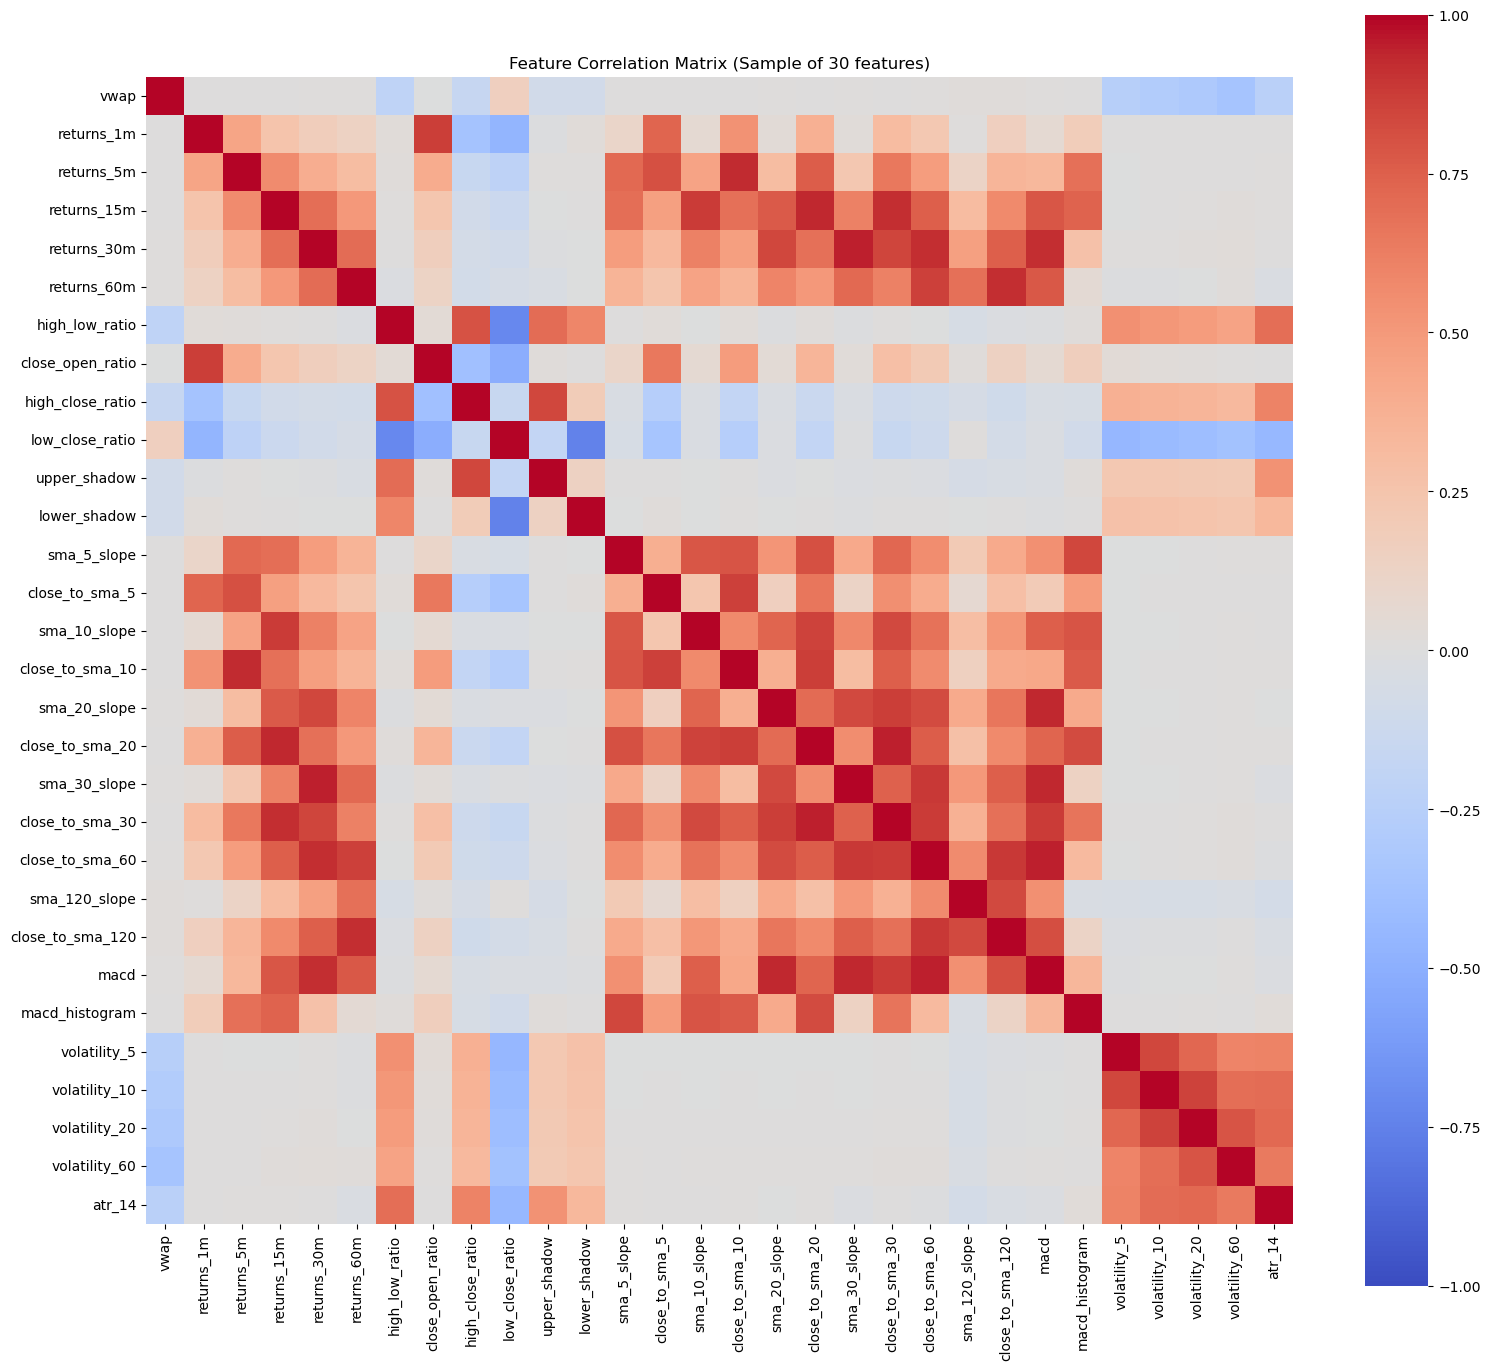


Final dataset shape: (250826, 82)
Final feature columns: 75


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def remove_highly_correlated_features(df, threshold=0.7):
    """
    Remove highly correlated features to reduce multicollinearity.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with features
    threshold : float
        Correlation threshold above which features are considered redundant
        
    Returns:
    --------
    tuple: (filtered DataFrame, list of dropped columns, correlation matrix)
    """
    # Exclude target columns and non-numeric columns
    target_cols = [col for col in df.columns if 'target' in col.lower()]
    non_feature_cols = target_cols + ['open', 'high', 'low', 'close', 'volume']
    
    # Get only numeric feature columns
    feature_cols = [col for col in df.columns 
                   if col not in non_feature_cols 
                   and df[col].dtype in ['float64', 'int64', 'float32', 'int32']]
    
    # Create a copy with only feature columns
    df_features = df[feature_cols].copy()
    
    # Drop rows with NaN values for correlation calculation
    df_clean = df_features.dropna()
    
    # Calculate correlation matrix
    corr_matrix = df_clean.corr().abs()
    
    # Select upper triangle of correlation matrix
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper_triangle.columns 
               if any(upper_triangle[column] > threshold)]
    
    print(f"Correlation threshold: {threshold}")
    print(f"Features before filtering: {len(feature_cols)}")
    print(f"Features to drop (correlation > {threshold}): {len(to_drop)}")
    print(f"Features remaining: {len(feature_cols) - len(to_drop)}")
    
    # Create filtered dataframe
    cols_to_keep = [col for col in df.columns if col not in to_drop]
    df_filtered = df[cols_to_keep].copy()
    
    return df_filtered, to_drop, corr_matrix

# Apply correlation filtering
df_filtered, dropped_cols, corr_matrix = remove_highly_correlated_features(df_features, threshold=0.95)

print(f"\n{'='*60}")
print("Dropped features (highly correlated):")
print('='*60)
for i, col in enumerate(dropped_cols, 1):
    print(f"{i:3d}. {col}")

# Visualize correlation matrix for remaining features
remaining_feature_cols = [col for col in df_filtered.columns 
                         if col not in ['open', 'high', 'low', 'close', 'volume', 
                                        'target_close_60m', 'target_return_60m']
                         and df_filtered[col].dtype in ['float64', 'int64', 'float32', 'int32']]

# Plot correlation heatmap (sample of features for readability)
if len(remaining_feature_cols) > 30:
    sample_cols = remaining_feature_cols[:30]  # Take first 30 for visualization
else:
    sample_cols = remaining_feature_cols

plt.figure(figsize=(16, 14))
corr_sample = df_filtered[sample_cols].dropna().corr()
sns.heatmap(corr_sample, annot=False, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title(f'Feature Correlation Matrix (Sample of {len(sample_cols)} features)')
plt.tight_layout()
plt.show()

print(f"\nFinal dataset shape: {df_filtered.shape}")
print(f"Final feature columns: {len(remaining_feature_cols)}")

In [6]:
df_filtered

,open,high,low,close,volume,vwap,returns_1m,returns_5m,returns_15m,returns_30m,...,minute_sin,minute_cos,day_sin,volume_lag_1,volume_lag_5,volume_lag_15,volume_lag_30,volume_lag_60,target_close_60m,target_return_60m
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-13 09:00:00,578.2300,578.2300,576.2400,576.2400,8162.000000,576.8011,NaN,NaN,NaN,NaN,...,0.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,575.44,-0.001388
2025-01-13 09:01:00,576.1100,576.3400,576.0900,576.2100,4503.000000,576.1920,-0.000052,NaN,NaN,NaN,...,0.104528,0.994522,0.000000,8162.000000,NaN,NaN,NaN,NaN,575.64,-0.000989
2025-01-13 09:02:00,576.1900,576.1900,575.9700,576.0000,2514.000000,576.0587,-0.000364,NaN,NaN,NaN,...,0.207912,0.978148,0.000000,4503.000000,NaN,NaN,NaN,NaN,575.80,-0.000347
2025-01-13 09:03:00,575.8700,575.8700,575.6000,575.7600,3849.000000,575.6454,-0.000417,NaN,NaN,NaN,...,0.309017,0.951057,0.000000,2514.000000,NaN,NaN,NaN,NaN,575.74,-0.000035
2025-01-13 09:04:00,575.5600,575.5600,575.0900,575.3800,4457.000000,575.2997,-0.000660,NaN,NaN,NaN,...,0.406737,0.913545,0.000000,3849.000000,NaN,NaN,NaN,NaN,575.97,0.001025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-12 23:55:00,666.6669,666.6669,666.6669,666.6669,190.110569,666.6916,-0.000365,-0.000296,-0.000743,-0.000849,...,-0.500000,0.866025,0.433884,1623.187050,397.329748,1869.360046,249.456401,703.028319,NaN,NaN
2026-03-12 23:56:00,666.7000,666.7100,666.6600,666.6800,1487.248396,666.6948,0.000020,0.000135,-0.000690,-0.000929,...,-0.406737,0.913545,0.433884,190.110569,1181.446053,146.030457,156.276723,498.150319,NaN,NaN
2026-03-12 23:57:00,666.6900,666.6900,666.4788,666.4826,787.965470,666.5362,-0.000296,-0.000491,-0.000925,-0.001150,...,-0.309017,0.951057,0.433884,1487.248396,2214.654886,730.154790,751.934601,283.308134,NaN,NaN


# Data Preparation for Temporal Fusion Transformer

Prepare the data in the format required by PyTorch Forecasting's TFT implementation.

In [7]:
# Prepare data for TFT
# IMPORTANT: Use df_filtered (after correlation filtering) not df_features!
df_tft = df_filtered.copy()

# Ensure we have a proper timestamp column
if 'timestamp' not in df_tft.columns:
    df_tft = df_tft.reset_index()
    
# Check if we have a datetime-like column
time_col = None
for col in ['timestamp', 'datetime', 'date', 'time']:
    if col in df_tft.columns:
        time_col = col
        break

if time_col is None:
    # Check index
    if 'index' in df_tft.columns:
        df_tft = df_tft.rename(columns={'index': 'timestamp'})
        time_col = 'timestamp'
    else:
        raise ValueError("No timestamp column found!")

print(f"Using '{time_col}' as time column")

# Drop any remaining NaN values
df_tft = df_tft.dropna()

# Create time_idx (sequential integer index required by TFT)
if time_col:
    df_tft = df_tft.sort_values(time_col).reset_index(drop=True)
else:
    df_tft = df_tft.reset_index(drop=True)
df_tft['time_idx'] = range(len(df_tft))

# Add group column (required by TFT, use 'SPY' since we're predicting SPY/S&P500)
df_tft['group'] = 'SPY'

# Define feature columns
# Time-varying known reals: features we know in advance (time-based features)
time_varying_known_reals = ['hour_sin', 'hour_cos', 'minute_sin', 'minute_cos', 'day_sin', 'day_cos']
# Filter to only include columns that exist
time_varying_known_reals = [c for c in time_varying_known_reals if c in df_tft.columns]

# Columns to exclude from unknown reals (target, identifiers, time features already used)
exclude_cols = ['timestamp', 'datetime', 'index', 'time_idx', 'group', 'target_close_60m', 'target_return_60m', 
                'is_morning', 'is_afternoon'] + time_varying_known_reals

time_varying_unknown_reals = [col for col in df_tft.columns 
                              if col not in exclude_cols 
                              and col not in ['hour', 'minute', 'day_of_week', 'month']
                              and df_tft[col].dtype in ['float64', 'int64', 'float32', 'int32']]

# Make sure 'close' is the first feature (it's our target)
if 'close' in time_varying_unknown_reals:
    time_varying_unknown_reals.remove('close')
time_varying_unknown_reals = ['close'] + time_varying_unknown_reals

# Time-varying known categoricals (discrete time features)
time_varying_known_categoricals = ['is_morning', 'is_afternoon']
time_varying_known_categoricals = [c for c in time_varying_known_categoricals if c in df_tft.columns]

print(f"Dataset shape: {df_tft.shape}")
print(f"\nTime-varying known reals: {len(time_varying_known_reals)} features")
print(f"Time-varying unknown reals: {len(time_varying_unknown_reals)} features")

Using 'timestamp' as time column
Dataset shape: (250642, 85)

Time-varying known reals: 5 features
Time-varying unknown reals: 70 features


In [8]:
# Import pytorch-forecasting components
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer, TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

# Define sequence lengths
max_encoder_length = 60  # 60 minutes of history
max_prediction_length = 60  # Predict 60 minutes ahead

# Training cutoff (80% of data for training)
training_cutoff = int(len(df_tft) * 0.8)

# Filter out any columns that don't exist in df_tft
time_varying_known_reals = [c for c in time_varying_known_reals if c in df_tft.columns]
time_varying_unknown_reals = [c for c in time_varying_unknown_reals if c in df_tft.columns]

print(f"Total data points: {len(df_tft)}")
print(f"Training cutoff at time_idx: {training_cutoff}")
print(f"Training samples: {training_cutoff}")
print(f"Validation samples: {len(df_tft) - training_cutoff}")

# Create training TimeSeriesDataSet
training = TimeSeriesDataSet(
    df_tft[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="close",
    group_ids=["group"],
    min_encoder_length=max_encoder_length // 2,  # Allow for shorter sequences
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["group"],
    static_reals=[],
    time_varying_known_categoricals=[],
    time_varying_known_reals=time_varying_known_reals,
    time_varying_unknown_categoricals=[],
    time_varying_unknown_reals=time_varying_unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=["group"],
        transformation="softplus"  # Ensures positive values
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Create validation dataset - use data AFTER training cutoff
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_tft[lambda x: x.time_idx > training_cutoff],
    predict=False,  # Set to False for proper validation with full sequences
    stop_randomization=True
)

# Create dataloaders
batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

print(f"\nTraining dataset size: {len(training)}")
print(f"Validation dataset size: {len(validation)}")

# Create TFT model from training dataset
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    output_size=7,  # 7 quantiles by default
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"\nTFT model created with {sum(p.numel() for p in tft.parameters())} parameters")
print(f"Number of continuous features: {len(training.reals)}")

Total data points: 250642
Training cutoff at time_idx: 200513
Training samples: 200513
Validation samples: 50129

Training dataset size: 200573
Validation dataset size: 50187

TFT model created with 256134 parameters
Number of continuous features: 79


# Temporal Fusion Transformer Model Training

Configure and train the TFT model with attention mechanisms for interpretable predictions.

In [9]:
# Check versions and GPU availability
import torch
import pytorch_lightning as pl
import pytorch_forecasting
print(f"PyTorch version: {torch.__version__}")
print(f"pytorch_lightning: {pl.__version__}")
print(f"pytorch_forecasting: {pytorch_forecasting.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1+cu121
pytorch_lightning: 2.0.9
pytorch_forecasting: 1.6.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# Configure PyTorch Lightning Trainer
import lightning.pytorch as pl
from lightning.pytorch.callbacks import (
    EarlyStopping, 
    LearningRateMonitor,
    ModelCheckpoint
)

print("Setting up training configuration...")

# Early stopping callback
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=10,
    verbose=True,
    mode="min"
)

# Learning rate monitor
lr_monitor = LearningRateMonitor(logging_interval="epoch")

# Model checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    dirpath="checkpoints/tft",
    filename="tft-{epoch:02d}-{val_loss:.4f}",
    save_top_k=3,
    mode="min",
)

# Create trainer (without TensorBoard logger)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="auto",
    enable_model_summary=True,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, lr_monitor, checkpoint_callback],
)

print("\nTrainer configured successfully!")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


Setting up training configuration...

Trainer configured successfully!


In [11]:
# Train the model
print("Starting TFT training...")
print("=" * 60)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

print("\nTraining complete!")
print(f"Best model checkpoint: {checkpoint_callback.best_model_path}")

You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting TFT training...



   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 1      | train | 0    
3  | prescalers                         | ModuleDict                      | 2.5 K  | train | 0    
4  | static_variable_selection          | VariableSelectionNetwork        | 5.8 K  | train | 0    
5  | encoder_variable_selection         | VariableSelectionNetwork        | 185 K  | train | 0    
6  | decoder_variable_selection         | VariableSelectionNetwork        | 11.9 K | train | 0    
7  | static_context_variable_selection  | GatedResidualNetwork            | 4.3 K  | train | 0    
8  

Epoch 0: 100%|██████████| 3133/3133 [19:27<00:00,  2.68it/s, v_num=7, train_loss_step=0.876, val_loss=1.530, train_loss_epoch=1.370]

Metric val_loss improved. New best score: 1.534


...

Epoch 7: 100%|██████████| 3133/3133 [20:06<00:00,  2.60it/s, v_num=7, train_loss_step=0.454, val_loss=1.320, train_loss_epoch=0.492]

Metric val_loss improved by 0.136 >= min_delta = 0.0001. New best score: 1.319


Epoch 9: 100%|██████████| 3133/3133 [19:35<00:00,  2.67it/s, v_num=7, train_loss_step=0.476, val_loss=1.560, train_loss_epoch=0.451]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 3133/3133 [19:35<00:00,  2.67it/s, v_num=7, train_loss_step=0.476, val_loss=1.560, train_loss_epoch=0.451]

Training complete!
Best model checkpoint: C:\Users\batzi\OneDrive\Dokumente\trading_brains\checkpoints\tft\tft-epoch=07-val_loss=1.3186.ckpt


# Model Evaluation & Predictions

Generate predictions and analyze model performance with visualization.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Generating predictions on validation set...
Predictions shape: torch.Size([50187, 60])
Collected 50069 valid prediction pairs (filtered NaN)

MODEL PERFORMANCE METRICS (60-minute ahead prediction)
Mean Absolute Error (MAE): $1.95
Root Mean Squared Error (RMSE): $2.75
Mean Absolute Percentage Error (MAPE): 0.28%
R² Score: 0.8226


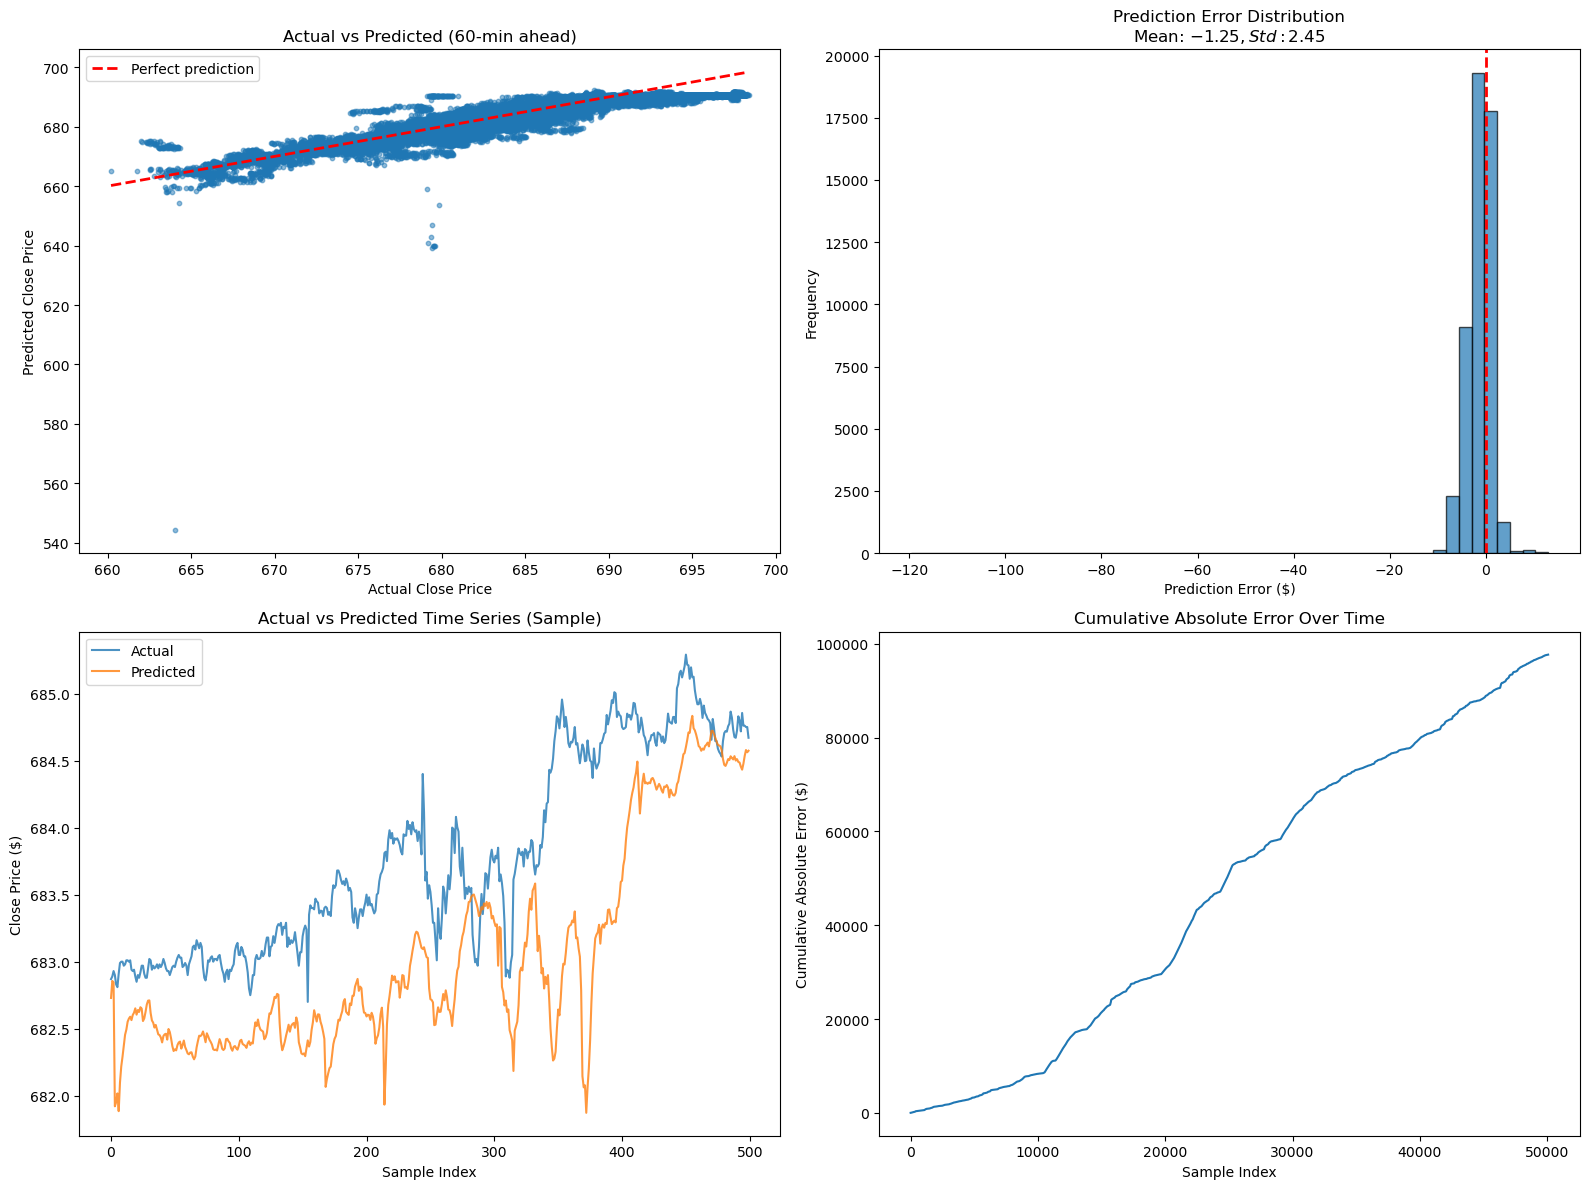

In [17]:
# Load best model
best_model_path = checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# Generate predictions on validation set
print("Generating predictions on validation set...")

# predict() returns: (predictions, x_dict, None, None, None) in this version
raw_output = best_tft.predict(val_dataloader, return_x=True, mode="prediction")
predictions = raw_output[0]

print(f"Predictions shape: {predictions.shape}")

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Collect actuals and predictions
actuals_list = []
pred_list = []

# Re-run through dataloader to collect actuals aligned with predictions
batch_idx = 0
for x_batch, y in val_dataloader:
    actual_target = y[0]  # Target values (batch, prediction_length)
    batch_size = actual_target.shape[0]
    batch_preds = predictions[batch_idx:batch_idx + batch_size]
    
    for i in range(batch_size):
        if i < batch_preds.shape[0]:
            # Get actual last timestep
            actual_val = actual_target[i, -1].item()
            # Predictions are 2D: (batch, prediction_length) - point predictions
            pred_val = batch_preds[i, -1].item()
            actuals_list.append(actual_val)
            pred_list.append(pred_val)
    
    batch_idx += batch_size

actuals_np = np.array(actuals_list)
pred_np = np.array(pred_list)

# Filter out NaN values
valid_mask = ~(np.isnan(actuals_np) | np.isnan(pred_np))
actuals_np = actuals_np[valid_mask]
pred_np = pred_np[valid_mask]

print(f"Collected {len(actuals_np)} valid prediction pairs (filtered NaN)")

# Calculate metrics
mae = mean_absolute_error(actuals_np, pred_np)
rmse = np.sqrt(mean_squared_error(actuals_np, pred_np))
mape = np.mean(np.abs((actuals_np - pred_np) / actuals_np)) * 100
r2 = r2_score(actuals_np, pred_np)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE METRICS (60-minute ahead prediction)")
print("=" * 60)
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"R² Score: {r2:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Actual vs Predicted
ax1 = axes[0, 0]
ax1.scatter(actuals_np, pred_np, alpha=0.5, s=10)
ax1.plot([actuals_np.min(), actuals_np.max()], 
         [actuals_np.min(), actuals_np.max()], 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('Actual Close Price')
ax1.set_ylabel('Predicted Close Price')
ax1.set_title('Actual vs Predicted (60-min ahead)')
ax1.legend()

# Plot 2: Prediction error distribution
ax2 = axes[0, 1]
errors = pred_np - actuals_np
ax2.hist(errors, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=0, color='r', linestyle='--', lw=2)
ax2.set_xlabel('Prediction Error ($)')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Prediction Error Distribution\nMean: ${errors.mean():.2f}, Std: ${errors.std():.2f}')

# Plot 3: Time series sample
ax3 = axes[1, 0]
sample_size = min(500, len(actuals_np))
ax3.plot(actuals_np[:sample_size], label='Actual', alpha=0.8)
ax3.plot(pred_np[:sample_size], label='Predicted', alpha=0.8)
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Close Price ($)')
ax3.set_title('Actual vs Predicted Time Series (Sample)')
ax3.legend()

# Plot 4: Cumulative error
ax4 = axes[1, 1]
cumulative_errors = np.cumsum(np.abs(errors))
ax4.plot(cumulative_errors)
ax4.set_xlabel('Sample Index')
ax4.set_ylabel('Cumulative Absolute Error ($)')
ax4.set_title('Cumulative Absolute Error Over Time')

plt.tight_layout()
plt.show()

MAE: $1.95
RMSE: $2.75
MAPE: 0.28%
R² Score: 0.82

The model achieved:
MAE: $1.95 (average error of ~$2 per prediction)
MAPE: 0.28% (very low percentage error)
R²: 0.82 (explains 82% of variance)

# Feature Importance & Interpretability

Analyze variable importance and attention patterns from the TFT model.

Getting raw model output for interpretation...

FEATURE IMPORTANCE ANALYSIS

Interpretation keys: ['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram']

Encoder variables tensor shape: torch.Size([76])
Var importance shape: (76,)
Number of variable names: 79

Encoder Variable Importance (Top 20):
  1. minute_cos: 20.1684
  2. high: 13.1657
  3. close_to_sma_10: 1.7747
  4. hour_cos: 1.0371
  5. rsi_14: 0.9560
  6. close_scale: 0.9419
  7. close_to_sma_30: 0.9234
  8. volume_sma_5: 0.8936
  9. bb_std_20: 0.8915
  10. close: 0.7427
  11. sma_30_slope: 0.7408
  12. mfi_60: 0.7280
  13. bb_std_60: 0.7133
  14. stoch_k_14: 0.6451
  15. minute_sin: 0.6440
  16. atr_60: 0.6190
  17. roc_20: 0.6185
  18. upper_shadow: 0.6175
  19. close_center: 0.5972
  20. volume_ratio_20: 0.5935


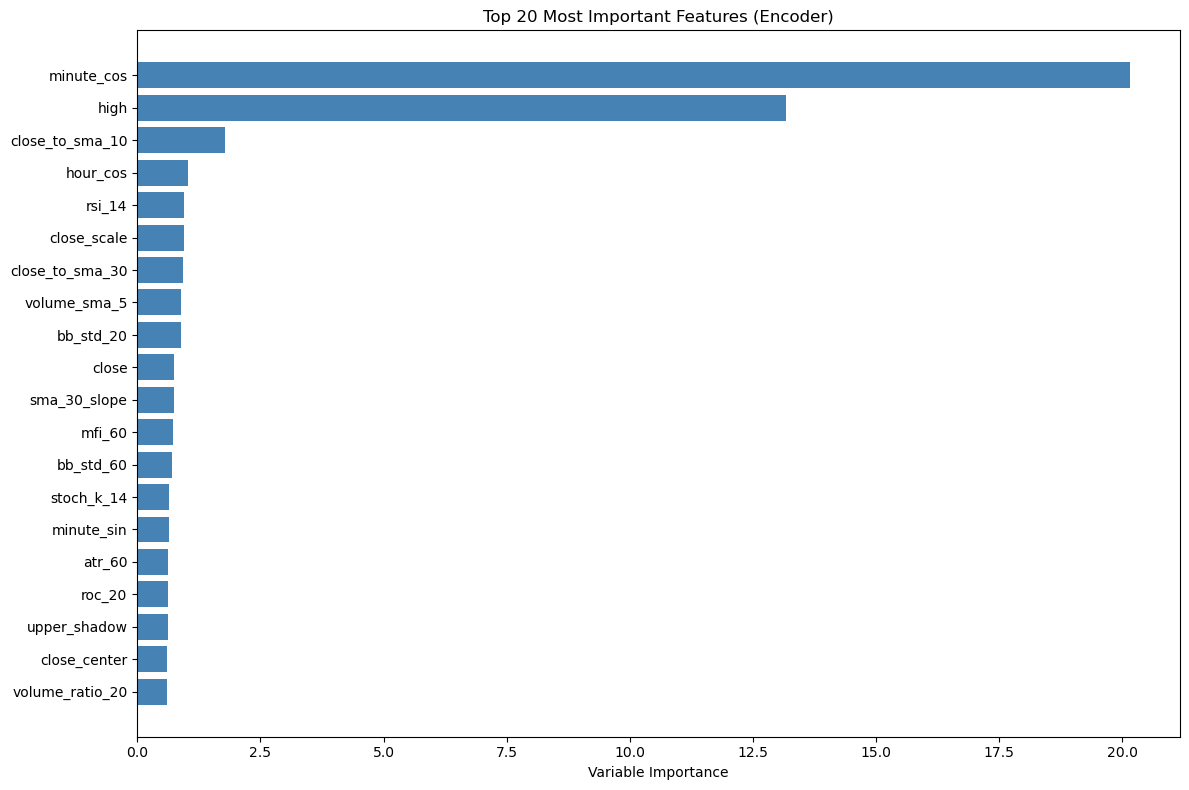


Decoder variables shape: torch.Size([6])

Static variables shape: torch.Size([4])

Attention shape: torch.Size([60])
Attention is 1D or scalar: tensor([0.4095, 0.4915, 0.4402, 0.4315, 0.4415, 0.4635, 0.4856, 0.5089, 0.5328,
        0.5563, 0.5896, 0.6206, 0.6487, 0.6770, 0.7036, 0.7314, 0.7675, 0.8032,
        0.8408, 0.8746, 0.9006, 0.9249, 0.9451, 0.9638, 0.9806, 0.9913, 1.0037,
        1.0065, 1.0152, 1.0181, 1.0248, 1.0390, 1.0489, 1.0590, 1.0744, 1.0897,
        1.1058, 1.1244, 1.1411, 1.1623, 1.1831, 1.2093, 1.2338, 1.2586, 1.2837,
        1.3116, 1.3457, 1.3774, 1.4166, 1.4567, 1.4983, 1.5446, 1.6053, 1.6653,
        1.7380, 1.8255, 1.9257, 2.0369, 2.1604, 2.2860])


In [21]:
# Get raw predictions with attention weights for interpretation
# We need mode="raw" to get the full output dictionary with attention info
print("Getting raw model output for interpretation...")

# Use a smaller subset of validation data for interpretation (faster)
small_val_loader = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

# Get a single batch for interpretation
for x_sample, y_sample in small_val_loader:
    break

# Run model forward pass manually to get raw output
best_tft.eval()
with torch.no_grad():
    raw_out = best_tft(x_sample)

# Now interpret the output
interpretation = best_tft.interpret_output(raw_out, reduction="sum")

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE ANALYSIS")  
print("=" * 60)

print(f"\nInterpretation keys: {list(interpretation.keys())}")

# Get encoder variable importance
encoder_vars = interpretation.get('encoder_variables')
if encoder_vars is not None:
    print(f"\nEncoder variables tensor shape: {encoder_vars.shape}")
    
    # Convert to numpy - it's already reduced so it's 1D
    var_importance = encoder_vars.cpu().numpy()
    print(f"Var importance shape: {var_importance.shape}")
    
    # Get variable names from training dataset
    var_names = list(training.reals)
    print(f"Number of variable names: {len(var_names)}")
    
    # Make sure dimensions match
    n_vars = min(len(var_importance), len(var_names))
    
    print("\nEncoder Variable Importance (Top 20):")
    # Sort by importance
    sorted_idx = np.argsort(var_importance)[::-1]
    for i, idx in enumerate(sorted_idx[:20]):
        if idx < n_vars:
            print(f"  {i+1}. {var_names[idx]}: {var_importance[idx]:.4f}")
    
    # Plot top features
    top_n = min(20, n_vars)
    top_vars = [var_names[i] for i in sorted_idx[:top_n] if i < n_vars]
    top_importance = [var_importance[i] for i in sorted_idx[:top_n] if i < n_vars]
    
    if len(top_vars) > 0:
        plt.figure(figsize=(12, 8))
        bars = plt.barh(range(len(top_vars)), top_importance[::-1], color='steelblue')
        plt.yticks(range(len(top_vars)), top_vars[::-1])
        plt.xlabel('Variable Importance')
        plt.title(f'Top {len(top_vars)} Most Important Features (Encoder)')
        plt.tight_layout()
        plt.show()
else:
    print("No encoder variable importance available")

# Get decoder variable importance
decoder_vars = interpretation.get('decoder_variables')
if decoder_vars is not None:
    print(f"\nDecoder variables shape: {decoder_vars.shape}")

# Get static variable importance  
static_vars = interpretation.get('static_variables')
if static_vars is not None:
    print(f"\nStatic variables shape: {static_vars.shape}")

# Get attention weights
attention = interpretation.get('attention')
if attention is not None:
    print(f"\nAttention shape: {attention.shape}")
    
    # Plot attention heatmap
    if attention.dim() >= 2:
        avg_attention = attention.cpu().numpy()
        plt.figure(figsize=(12, 8))
        plt.imshow(avg_attention, aspect='auto', cmap='viridis')
        plt.colorbar(label='Attention Weight')
        plt.xlabel('Encoder Time Step')
        plt.ylabel('Decoder Time Step')
        plt.title('Attention Weights')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Attention is 1D or scalar: {attention}")
        

## Save Model for Future Use

In [27]:
# Save the trained model and dataset parameters for future use
import torch
import pickle
import shutil
from datetime import datetime
import os

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Generate timestamp for versioning
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Method 1: Copy the best checkpoint (recommended for PyTorch Lightning models)
checkpoint_dest = f'models/tft_checkpoint_{timestamp}.ckpt'
shutil.copy(best_model_path, checkpoint_dest)
print(f"Checkpoint copied to: {checkpoint_dest}")

# Also save as "latest" for easy access
shutil.copy(best_model_path, 'models/tft_checkpoint_latest.ckpt')
print(f"Latest checkpoint: models/tft_checkpoint_latest.ckpt")

# Method 2: Save the state dict (smaller, more portable)
state_dict_path = f'models/tft_state_dict_{timestamp}.pt'
torch.save(best_tft.state_dict(), state_dict_path)
print(f"State dict saved to: {state_dict_path}")

# Save the training dataset parameters needed to recreate the dataset for inference
dataset_params = {
    'time_idx': training.time_idx,
    'target': training.target,
    'group_ids': training.group_ids,
    'max_encoder_length': training.max_encoder_length,
    'max_prediction_length': training.max_prediction_length,
    'time_varying_known_categoricals': list(training.time_varying_known_categoricals),
    'time_varying_known_reals': list(training.time_varying_known_reals),
    'time_varying_unknown_reals': list(training.time_varying_unknown_reals),
    'static_categoricals': list(training.static_categoricals),
    'static_reals': list(training.static_reals),
    'categorical_encoders': training.categorical_encoders,
    'scalers': training.scalers,
    'target_normalizer': training.target_normalizer,
}

params_path = f'models/training_params_{timestamp}.pkl'
with open(params_path, 'wb') as f:
    pickle.dump(dataset_params, f)
print(f"Training parameters saved to: {params_path}")

# Save "latest" version of params
with open('models/training_params_latest.pkl', 'wb') as f:
    pickle.dump(dataset_params, f)

# Print file sizes
print(f"\nFile sizes:")
print(f"  Checkpoint: {os.path.getsize(checkpoint_dest) / (1024*1024):.2f} MB")
print(f"  State dict: {os.path.getsize(state_dict_path) / (1024*1024):.2f} MB")
print(f"  Parameters: {os.path.getsize(params_path) / 1024:.2f} KB")

print("\n" + "="*60)
print("To load the model in a new session:")
print("="*60)
print("""
from pytorch_forecasting import TemporalFusionTransformer
import pickle

# Load from checkpoint (recommended)
model = TemporalFusionTransformer.load_from_checkpoint('models/tft_checkpoint_latest.ckpt')

# Load training parameters
with open('models/training_params_latest.pkl', 'rb') as f:
    params = pickle.load(f)
""")

Checkpoint copied to: models/tft_checkpoint_20260313_123439.ckpt
Latest checkpoint: models/tft_checkpoint_latest.ckpt
State dict saved to: models/tft_state_dict_20260313_123439.pt
Training parameters saved to: models/training_params_20260313_123439.pkl

File sizes:
  Checkpoint: 4.53 MB
  State dict: 1.55 MB
  Parameters: 2.26 KB

To load the model in a new session:

from pytorch_forecasting import TemporalFusionTransformer
import pickle

# Load from checkpoint (recommended)
model = TemporalFusionTransformer.load_from_checkpoint('models/tft_checkpoint_latest.ckpt')

# Load training parameters
with open('models/training_params_latest.pkl', 'rb') as f:
    params = pickle.load(f)



# Make Predictions on New Data

Function to generate hourly price predictions using the trained model.

In [25]:
def predict_next_hour_from_prepared_data(model, df_prepared, training_dataset, encoder_length=60, prediction_length=60):
    """
    Generate prediction for the next 60 minutes using already prepared data.
    
    Parameters:
    -----------
    model : TemporalFusionTransformer
        Trained TFT model
    df_prepared : pd.DataFrame
        Data already processed with features (like df_tft)
    training_dataset : TimeSeriesDataSet
        Original training dataset for parameters
    encoder_length : int
        Number of historical steps needed
    prediction_length : int
        Number of future steps to predict
        
    Returns:
    --------
    dict: Prediction results
    """
    # Need enough data for encoder + prediction
    min_rows = encoder_length + prediction_length + 10
    df_pred = df_prepared.tail(min_rows).copy()
    df_pred = df_pred.reset_index(drop=True)
    df_pred['time_idx'] = np.arange(len(df_pred))
    df_pred['group'] = 'SPY'  # Must match training group!
    
    print(f"Prepared prediction data shape: {df_pred.shape}")
    print(f"Required: encoder({encoder_length}) + prediction({prediction_length}) = {encoder_length + prediction_length}")
    
    # Create prediction dataset with predict=False to get proper sequences
    # (predict=True only gives last sequence which may not have enough data)
    pred_dataset = TimeSeriesDataSet.from_dataset(
        training_dataset,
        df_pred,
        predict=False,  # Get all valid sequences
        stop_randomization=True,
        min_prediction_idx=0,  # Allow predictions from start
    )
    
    print(f"Prediction dataset size: {len(pred_dataset)}")
    
    if len(pred_dataset) == 0:
        print("Warning: No valid samples in prediction dataset!")
        print("This usually means not enough data for encoder + prediction length")
        return None
    
    pred_dataloader = pred_dataset.to_dataloader(
        train=False,
        batch_size=len(pred_dataset),  # Get all predictions at once
        num_workers=0
    )
    
    # Generate predictions
    model.eval()
    raw_preds = model.predict(pred_dataloader, mode="prediction")
    predictions = raw_preds[0] if isinstance(raw_preds, tuple) else raw_preds
    
    print(f"Predictions shape: {predictions.shape}")
    
    # Use the last prediction (most recent data)
    if predictions.ndim == 2:
        # Point prediction - 2D tensor (batch, prediction_length)
        # Take the last batch sample (most recent)
        last_pred = predictions[-1]
        results = {
            'prediction_60min': last_pred[-1].item(),
            'prediction_all_steps': last_pred.cpu().numpy(),
        }
    elif predictions.ndim == 3:
        # Quantile prediction - 3D tensor
        last_pred = predictions[-1]
        results = {
            'prediction_60min': last_pred[-1, 3].item(),
            'lower_bound_90': last_pred[-1, 1].item(),
            'upper_bound_90': last_pred[-1, 5].item(),
        }
    else:
        results = {'raw_predictions': predictions.cpu().numpy()}
    
    return results

# Example usage with already prepared df_tft data
print("Example: Predicting next hour's closing price")
print("=" * 60)

# Use the already prepared df_tft (which has all features and no NaN)
prediction = predict_next_hour_from_prepared_data(
    best_tft, df_tft, training, 
    max_encoder_length, max_prediction_length
)

if prediction:
    print(f"\nPrediction for 60 minutes ahead:")
    if 'prediction_60min' in prediction:
        print(f"  Predicted close price: ${prediction['prediction_60min']:.2f}")
    if 'lower_bound_90' in prediction:
        print(f"  90% confidence interval: [${prediction['lower_bound_90']:.2f}, ${prediction['upper_bound_90']:.2f}]")
    if 'prediction_all_steps' in prediction:
        print(f"\n  Predictions at different horizons:")
        steps = prediction['prediction_all_steps']
        print(f"  +15 min: ${steps[14]:.2f}")
        print(f"  +30 min: ${steps[29]:.2f}")
        print(f"  +45 min: ${steps[44]:.2f}")
        print(f"  +60 min: ${steps[59]:.2f}")
else:
    print("Prediction failed - check data preparation")

# Show the last known actual price for comparison
last_actual = df_tft['close'].iloc[-1]
print(f"\n  Last actual close price: ${last_actual:.2f}")

# Save model checkpoint path for future use
print("\n" + "=" * 60)
print("Model information:")
print(f"Best checkpoint: {best_model_path}")

# Save training dataset parameters for inference
import pickle
params_to_save = {
    'max_encoder_length': max_encoder_length,
    'max_prediction_length': max_prediction_length,
    'time_varying_known_reals': time_varying_known_reals,
    'time_varying_unknown_reals': time_varying_unknown_reals,
    'best_checkpoint_path': best_model_path,
}
with open('training_dataset_params.pkl', 'wb') as f:
    pickle.dump(params_to_save, f)
print("Training parameters saved to 'training_dataset_params.pkl'")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Example: Predicting next hour's closing price
Prepared prediction data shape: (130, 85)
Required: encoder(60) + prediction(60) = 120
Prediction dataset size: 189
Predictions shape: torch.Size([189, 60])

Prediction for 60 minutes ahead:
  Predicted close price: $666.84

  Predictions at different horizons:
  +15 min: $666.83
  +30 min: $666.80
  +45 min: $666.79
  +60 min: $666.84

  Last actual close price: $667.51

Model information:
Best checkpoint: C:\Users\batzi\OneDrive\Dokumente\trading_brains\checkpoints\tft\tft-epoch=07-val_loss=1.3186.ckpt
Training parameters saved to 'training_dataset_params.pkl'
